In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

e:\AgenticAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
model = init_chat_model("qwen/qwen3-32b", model_provider="groq")

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'Generate a joke on the topic: {state['topic']}'
    response = model.invoke((prompt)).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'Explain the joke: {state['joke']}'
    response = model.invoke((prompt)).content

    return {'explanation': response}

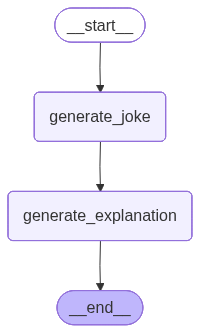

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [14]:
initial_state = {'topic': 'Burger'}
config1 = {'configurable': {'thread_id': '1'}}

workflow.invoke(initial_state, config=config1)

{'topic': 'Burger',
 'joke': '<think>\nOkay, I need to come up with a joke about burgers. Let\'s see... Burgers are a common food, so maybe I can play on words related to them. Words like "beef," "patty," "bun," "lettuce," "tomato," "cheese," "condiments," "grill," "fast food," "restaurant," etc. Maybe a pun? Or a play on a common phrase?\n\nHmm. Let me think of some possible angles. Maybe something about the ingredients? Like why a burger went to the doctor? Because it had too many "layers"? Wait, that\'s a bit cheesy. Maybe not. Or maybe a joke about a burger that\'s a "meaty" subject?\n\nWait, here\'s an idea. Why did the burger go to the doctor? Because it was feeling "stale" after being left out. But that\'s not very funny. Let me try another approach. Maybe involving a pun with "beef." Like "Why don\'t burgers ever get cold? Because they always wear a beef coat." No, that\'s forced.\n\nHow about a play on words with "grill"? Maybe a burger going to the grill and getting burned? N

In [15]:
print(workflow.get_state(config=config1))

StateSnapshot(values={'topic': 'Burger', 'joke': '<think>\nOkay, I need to come up with a joke about burgers. Let\'s see... Burgers are a common food, so maybe I can play on words related to them. Words like "beef," "patty," "bun," "lettuce," "tomato," "cheese," "condiments," "grill," "fast food," "restaurant," etc. Maybe a pun? Or a play on a common phrase?\n\nHmm. Let me think of some possible angles. Maybe something about the ingredients? Like why a burger went to the doctor? Because it had too many "layers"? Wait, that\'s a bit cheesy. Maybe not. Or maybe a joke about a burger that\'s a "meaty" subject?\n\nWait, here\'s an idea. Why did the burger go to the doctor? Because it was feeling "stale" after being left out. But that\'s not very funny. Let me try another approach. Maybe involving a pun with "beef." Like "Why don\'t burgers ever get cold? Because they always wear a beef coat." No, that\'s forced.\n\nHow about a play on words with "grill"? Maybe a burger going to the grill a

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': '<think>\nOkay, I need to come up with a joke about burgers. Let\'s see... Burgers are a common food, so maybe I can play on words related to them. Words like "beef," "patty," "bun," "lettuce," "tomato," "cheese," "condiments," "grill," "fast food," "restaurant," etc. Maybe a pun? Or a play on a common phrase?\n\nHmm. Let me think of some possible angles. Maybe something about the ingredients? Like why a burger went to the doctor? Because it had too many "layers"? Wait, that\'s a bit cheesy. Maybe not. Or maybe a joke about a burger that\'s a "meaty" subject?\n\nWait, here\'s an idea. Why did the burger go to the doctor? Because it was feeling "stale" after being left out. But that\'s not very funny. Let me try another approach. Maybe involving a pun with "beef." Like "Why don\'t burgers ever get cold? Because they always wear a beef coat." No, that\'s forced.\n\nHow about a play on words with "grill"? Maybe a burger going to the grill 